In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
  0% 0.00/25.7M [00:00<?, ?B/s]
100% 25.7M/25.7M [00:00<00:00, 1.33GB/s]


In [ ]:
!unzip /content/imdb-dataset-of-50k-movie-reviews.zip

Archive:  /content/imdb-dataset-of-50k-movie-reviews.zip
  inflating: IMDB Dataset.csv        


### Data loading & EDA

In [ ]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv" )
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
df.duplicated().sum()

np.int64(418)

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

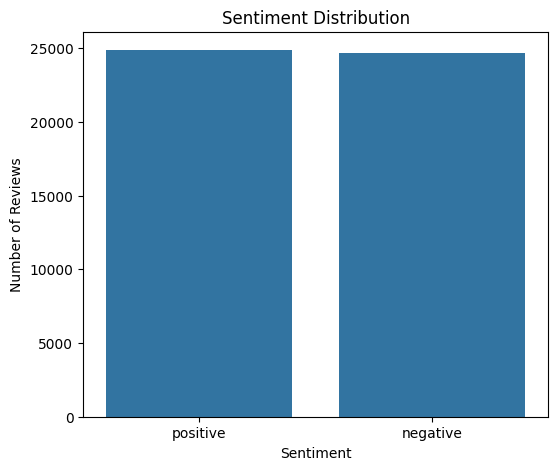

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(6 , 5))
sns.countplot(data= df, x='sentiment')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel('Number of Reviews')
plt.show()



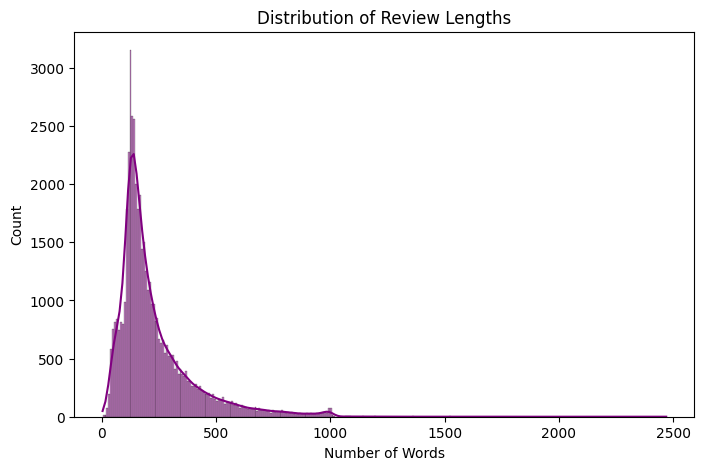

In [ ]:
df['review_len']= df['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['review_len'], kde=True, color='purple')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()



In [ ]:
df.drop(['review_len'], axis=1, inplace=True)


### Preprocessing text

In [ ]:
import html
import re

def strip_html_regex(text):
    if text is None:
        return ""
    text = re.sub(r'<[^>]+>', ' ', str(text))
    text = html.unescape(text)
    text = " ".join(text.split())
    return text
df['review'] = df['review'].apply(strip_html_regex)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
def remove_urls(text):
  text =re.sub(r"http\S+|www\S+|http\S+", "", text, flags= re.MULTILINE)
  return text
df['review'] = df['review'].apply(remove_urls)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
def to_lower(text):
 text = text.lower()
 return text
df["review"] = df["review"].apply(to_lower)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [ ]:
import string
def remove_punctuation(text):
  text =text.translate(str.maketrans("", "", string.punctuation))
  return text
df ['review'] = df['review'].apply(remove_punctuation)

df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [ ]:
def remove_special_char(text):
  text= re.sub(r"[^A-Za-z]"," ", text)
  return text
df["review"] = df["review"].apply(remove_special_char)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [ ]:
def normalize_repeated_chars(text):
  text = re.sub(r"(.)\1{2,}", r"\1\1", text)
  return text.strip()
df["review"] = df["review"].apply(normalize_repeated_chars)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [ ]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


True

In [ ]:
from nltk.tokenize import word_tokenize

def tokenize_text(text):
  tokens = word_tokenize(text)
  return tokens

tokens = df['review'].apply(tokenize_text)
tokens.head()

,review
0,"[one, of, the, other, reviewers, has, mentione..."
1,"[a, wonderful, little, production, the, filmin..."
2,"[i, thought, this, was, a, wonderful, way, to,..."
3,"[basically, theres, a, family, where, a, littl..."
4,"[petter, matteis, love, in, the, time, of, mon..."


In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords',quiet=True )

def remove_stopwords_preserve_negation(tokens):

    stop_words= set(stopwords.words('english'))
    negation_words = {
        'not', "n't", "no", "never", "none", "nobody", "nothing", "nowhere",
        "neither", "nor", "cannot", "can't", "won't", "wouldn't", "couldn't",
        "shouldn't", "isn't", "aren't", "wasn't", "weren't", "don't", "doesn't",
        "didn't", "haven't", "hasn't", "hadn't", "mustn't", "mightn't", "needn't"}

    filtered_stopwords= stop_words - negation_words

    filtered_tokens = [token for token in tokens if token not in filtered_stopwords]

    return filtered_tokens
filtered_tokens= tokens.apply(remove_stopwords_preserve_negation)
filtered_tokens.head()


,review
0,"[one, reviewers, mentioned, watching, oz, epis..."
1,"[wonderful, little, production, filming, techn..."
2,"[thought, wonderful, way, spend, time, hot, su..."
3,"[basically, theres, family, little, boy, jake,..."
4,"[petter, matteis, love, time, money, visually,..."


In [ ]:
import nltk
from nltk.corpus import wordnet
from nltk.stem.wordnet import WordNetLemmatizer

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
def get_wordnet_pos(treebank_tag):
   if treebank_tag.startswith('J'):
        return wordnet.ADJ
   elif treebank_tag.startswith('V'):
        return wordnet.VERB
   elif treebank_tag.startswith('N'):
        return wordnet.NOUN
   elif treebank_tag.startswith('R'):
        return wordnet.ADV
   else:
        return wordnet.NOUN


In [ ]:
def lemmatize_tokens_list(tokens):

   lem = WordNetLemmatizer()
   pos_tags= nltk.pos_tag(tokens)
   lemmatized = [lem.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags ]
   return lemmatized

lemmatized_tokens = filtered_tokens.apply(lemmatize_tokens_list)
lemmatized_tokens.head()



,review
0,"[one, reviewer, mention, watch, oz, episode, y..."
1,"[wonderful, little, production, film, techniqu..."
2,"[think, wonderful, way, spend, time, hot, summ..."
3,"[basically, there, family, little, boy, jake, ..."
4,"[petter, matteis, love, time, money, visually,..."


In [ ]:
df.loc[:, 'review'] = lemmatized_tokens.apply(lambda x: ' '.join(x))

df.head()


,review,sentiment
0,one reviewer mention watch oz episode youll ho...,positive
1,wonderful little production film technique una...,positive
2,think wonderful way spend time hot summer week...,positive
3,basically there family little boy jake think t...,negative
4,petter matteis love time money visually stunni...,positive


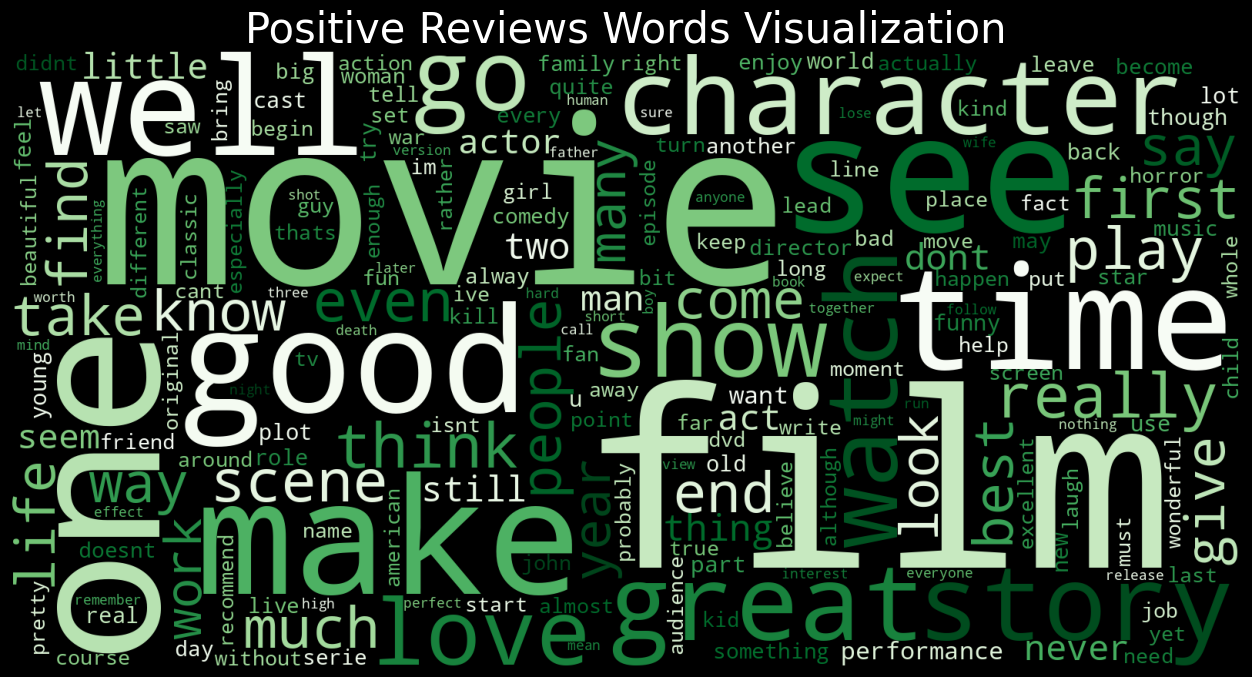

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_reviews = df[df['sentiment'] == "positive"]['review']
positive_text = " ".join(positive_reviews)
wordcount = WordCloud(
    width= 1600,
    height = 800,
    background_color= 'black',
    collocations=False,
    colormap='Greens').generate(positive_text)

plt.figure(figsize= (25, 8), facecolor='black')
plt.title('Positive Reviews Words Visualization', fontsize= 30, c= 'white')
plt.imshow(wordcount)
plt.axis('off')
plt.show()


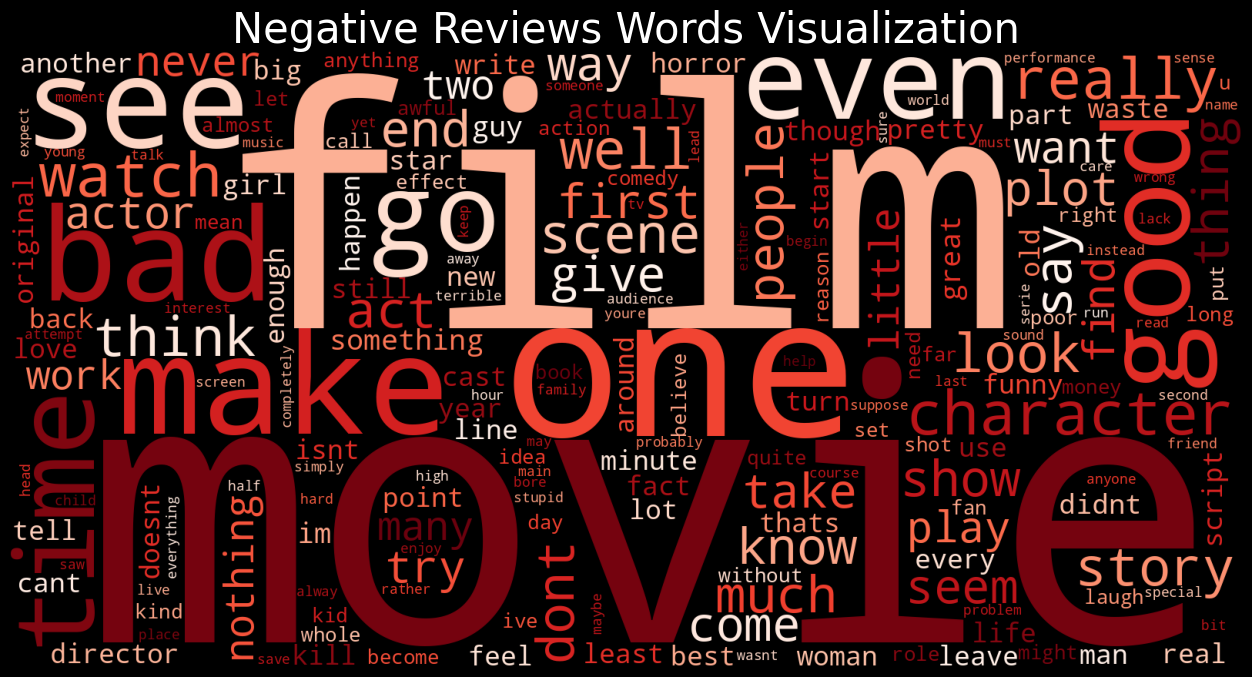

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negative_reviews = df[df['sentiment']== 'negative']['review']
negative_text = " ".join(negative_reviews)

wordcount_negative = WordCloud(
    width = 1600,
    height = 800,
    background_color= 'black',
    collocations = False,
    colormap = 'Reds').generate(negative_text)

plt.figure(figsize= (25, 8), facecolor= 'black')
plt.title("Negative Reviews Words Visualization", fontsize= 30, c= 'white' )
plt.imshow(wordcount_negative)
plt.axis('off')
plt.show()

In [ ]:
df.head()

,review,sentiment
0,one reviewer mention watch oz episode youll ho...,positive
1,wonderful little production film technique una...,positive
2,think wonderful way spend time hot summer week...,positive
3,basically there family little boy jake think t...,negative
4,petter matteis love time money visually stunni...,positive


In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df.head()

,review,sentiment
0,one reviewer mention watch oz episode youll ho...,1
1,wonderful little production film technique una...,1
2,think wonderful way spend time hot summer week...,1
3,basically there family little boy jake think t...,0
4,petter matteis love time money visually stunni...,1


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(stop_words= 'english', max_df= .95 , min_df=4 , max_features=5000)
x_bow_features = bow_vectorizer.fit_transform(df['review'])
x_bow_dense = x_bow_features.todense()

x_bow_dense

matrix([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words= 'english', max_df= .90 , min_df= 4 , max_features= 5000
)

tfidf_features = tfidf_vectorizer.fit_transform(df['review'])

tfidf_features =tfidf_features.toarray()
tfidf_features

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### Spliting data

In [ ]:
from sklearn.model_selection import train_test_split

X = tfidf_features
y = df["sentiment"]
X_train , X_test , y_train , y_test = train_test_split(X , y, test_size= .20 , random_state= 42, shuffle=True)


### Modeling LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report

log = LogisticRegression(max_iter= 1000, random_state= 42)
log.fit(X_train, y_train)

y_pred_train= log.predict(X_train)
y_pred_test= log.predict(X_test)

print(f"Accuracy of train: {accuracy_score(y_train, y_pred_train)*100:.3f}")
print(f"Accuracy of test: { accuracy_score(y_test, y_pred_test)*100:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))


Accuracy of train: 90.652
Accuracy of test: 87.698

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.86      0.87      4939
           1       0.87      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



Modeling  NAIVE BAYES CLASSIFIER


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_train_nb= nb.predict(X_train)
y_pred_test_nb= nb.predict(X_test)


print(f"Accuracy of train: {accuracy_score(y_train, y_pred_train_nb)*100:.3f}")
print(f"Accuracy of test: { accuracy_score(y_test, y_pred_test_nb)*100:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_nb))




Accuracy of train: 85.897
Accuracy of test: 84.653

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84      4939
           1       0.84      0.85      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917

